# OLG model

Imports and set magics:

In [564]:
import numpy as np
from scipy import optimize
import sympy as sp
from types import SimpleNamespace
import matplotlib.pyplot as plt
# autoreload modules when code is run
%load_ext autoreload
%autoreload 2

# local modules
from modelproject import OLGModelClass
from modelproject import OLGPAYG

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Model description

Our project analyses the Overlapping generations (OLG) model. The OLG model is a cornerstone model of modern economics. It investigates intergeneraltional allocation and the life-cycle behavior (investment in human capital, work and saving for retirement). 

In the OLG model, we have 2 periods, one when individuals are young, period 1 and one when they are old, period t+1. 
Induviduals are born in period t.

$$L_t =L_{t+1}$$

There are $L_t$ young people and $L_{t+1}$ old people. We have no population growth in our OLG model.

**Firms**: We have in the OLG model that firms are competitive, identical and maximize their profits as such:

$$
\begin{aligned}
\pi_t & =\max_{K_{t},L_t} K_t^\alpha L_t^{1-\alpha}-r_tK_t-w_tL_t\\
\end{aligned}
$$
This is a Cobb-Douglas production-function. $K_{t}$ is the capital, $L_t$ is the labor, $\alpha$ is a parameter, $\in (0, 1)$.

We define kapital in per capita terms, and we have that the rent on capital is its marginal product. And the cost of labour is the wage which is also its marginal product.
$$
\begin{aligned}
k_t & =\frac{K_t}{L_t} \\
r_t & = \alpha  k_t^{\alpha-1} \\
w_t & = (1-\alpha)  k_t^{\alpha}
\end{aligned}
$$


The budget constraint for the young and old is: 

$$
c_{1t} + s_t = w_t 
$$

$$
c_{2t+1} = (1 + r_{t+1}) s_t
$$

The young consume their wage and saves for when they are old. The old then get these savings and the interest rate they got on the savings. 

The lifetime budget constraint then becomes:

$$c_{1t} + \frac{c_{2t+1}}{1+r_{t+1}} = w_t $$

The old consumes all of their remaining saved wages. We see that all consumtion comes from the wage made in period 1. 

Utility for the households is:
    
$$
\begin{aligned}
U_t & = u(c_{1t})+\frac{1}{1+\rho} u(c_{2t+1})\\
\end{aligned}
$$

$\rho$ is the discount rate, i.e. the measure of patience of the households, i.e. how much consumption the househoplds wants when young in period 1 and when old in period 2. A higher $\rho$ means more impatient households, $\rho \in (0,1)$.

We can now solve the households maximization problem:

$$ \max_{c_{1t}, c_{2t+1}} \left( u(c_{1t}) + \frac{1}{1+\rho} u(c_{2t+1}) \right) $$

Subject to the budget constraint:

$$ c_{1t} + \frac{c_{2t+1}}{1+r_{t+1}} = W_t $$

We can now solve this using sympy, and find the OLG-euler.

FOC for our OLG model


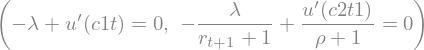

In [565]:
from sympy import symbols, Function, diff, Eq, solve, init_printing

init_printing()

# We start by defining our symbols to use in Sympy
c1t, c2t1, wt, wt1, rt1, rho, lam, st, alpha, kt, kt1, n, tau = symbols('c1t c2t1 w_t w_{t+1} r_{t+1} rho lambda s_t alpha k_t k_{t+1} n tau')

# Utility functions
u = Function('u')

# We set up the Lagrangian
L = u(c1t) + 1 / (1 + rho) * u(c2t1) + lam * (wt - c1t - c2t1 / (1 + rt1))

# And compute the FOC
foc_c1t = diff(u(c1t), c1t) - lam
foc_c2t1 = diff(u(c2t1), c2t1) / (1 + rho) - lam / (1 + rt1)

u_prime_c1t = symbols("u'(c1t)")
u_prime_c2t1 = symbols("u'(c2t1)")
foc_c1t = foc_c1t.subs(diff(u(c1t), c1t), u_prime_c1t)
foc_c2t1 = foc_c2t1.subs(diff(u(c2t1), c2t1), u_prime_c2t1)

# Formatting
eq1 = Eq(foc_c1t, 0)
eq2 = Eq(foc_c2t1, 0)
print("FOC for our OLG model")

eq1, eq2

Intertemporal euler equation


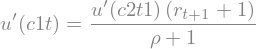

In [566]:
# we solve for lambda from eq1 and substitute in eq2
lambda_from_eq1 = solve(eq1, lam)[0]
euler_eq = eq2.subs(lam, lambda_from_eq1)

# We now solve the Euler equation for u_prime_c1t
euler_solution = solve(euler_eq, u_prime_c1t)

u_prime = lambda c: 1 / c

# Formatting
euler_solution_eq = sp.Eq(u_prime_c1t, euler_solution[0])
print("Intertemporal euler equation")
euler_solution_eq

We have now found the Euler equation for the OLG. If we combine the budget constraints with the euler we can find the optimal savings in our baseline OLG economy. 

Optimal savings


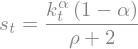

In [567]:
#We define our rental rate of capital and our wage rate
rt = alpha  * kt**(alpha - 1)
rt1 = alpha  * kt1**(alpha - 1)
wt = (1 - alpha)  * kt**alpha
wt1 = (1 - alpha)  * kt1**alpha

#And our budget constraint, the consumption in period one when young, and period 2 when old
c1t = wt - st
c2t1 = (1 + rt1) * st

# We define u' as a function
u_prime = lambda c: 1 / c

# The euler equation expressed in terms of st and wt
savings_rate = sp.Eq(u_prime(c1t), (1 + rt1)*u_prime(c2t1) / (1 + rho))

optimal_savings = sp.solve(savings_rate, st)[0]

ste=sp.Eq(st , optimal_savings)
print("Optimal savings")
ste


So the optimal savings rate is: 

$$s_t=1/(2+\rho)w_t$$

We see that the optimal savings depends on the wage rate and the time preference $\rho$. As $\rho$ increases (indicating a higher preference for present consumption), the savings rate decreases.  Higher wage income leads to higher savings, assuming the savings rate remains constant.

We can now find the capital accumulation $k_{t+1}$

Capital accumulation in baseline OLG


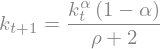

In [568]:
kt1e=sp.Eq(kt1, optimal_savings)
print("Capital accumulation in baseline OLG")
kt1e

The savings rate and capital accumulation are the same because the savings of the working generation form the capital stock for the next period.

We can now find the steady state by setting $k_t=k_{t+1}=k*$

Steady state for our baseline OLG


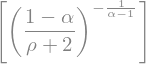

In [569]:
# We solve for the steady state 
steady_state_eq = kt1e.subs(kt1, kt)
steady_state_solution = sp.solve(steady_state_eq, kt)
print("Steady state for our baseline OLG")
steady_state_solution

We see that the steady state depends on the time preference $\rho$ and the output elasticity of capital $\alpha$. Steady state is negativly affected by the time preference rate and positively affected by the output elasticity of capital. Higher $\rho$ leads to lower savings and capital accumulation, while higher $\alpha$ increases the steady-state capital. 

We can assign numeric values to $\alpha$ and $\rho$ to find the steady state value.

In [570]:
Steady_state_nums = sp.lambdify((rho,alpha),steady_state_solution)
print("Steady state value")
Steady_state_nums(0.03, 0.35)

Steady state value


For the chosen parameter values, we find that steady state is $k^*=0.173$

We can now set up an algorithm that solves our steady state, we use the bisect method. 

# Numerical analysis

In [571]:
# We set parameter values
rho = 0.03
alpha = 0.35

kss=((1-alpha)/((2+rho))**1/(1-alpha))

# We define the objective of the function, it calculates the difference between k and the expression, The goal is to find the value of k for which this difference is zero. 
obj = lambda k: k - (((1-alpha)*k**alpha)/(2+rho))

# Optimizing the model and finding the roots with bisect, we do this to plot the convergens in the next sample of code
result = optimize.root_scalar(obj,bracket=[1e-10,10],method='bisect') 

initializing the model:
calling .setup()
calling .allocate()
simulation done in 0.00 secs


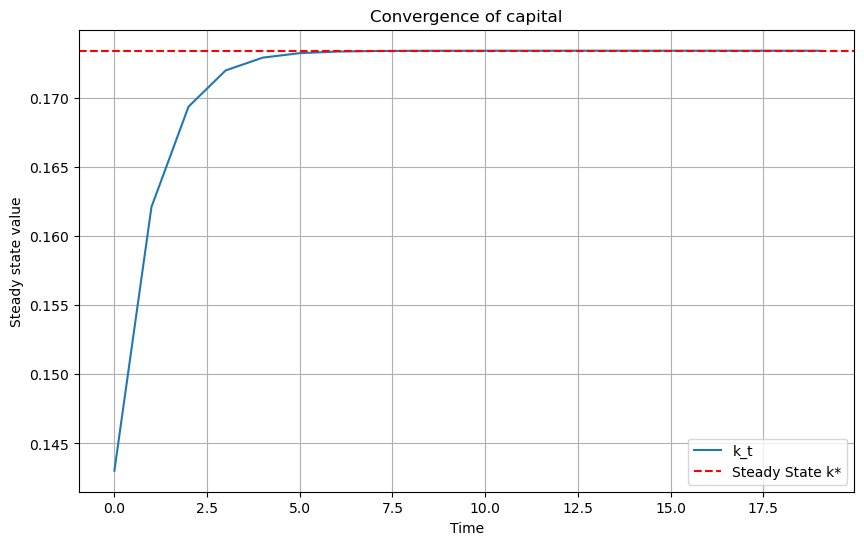

In [572]:
# We call in the simulation of our OLG model we have constructed in our .py file
model = OLGModelClass()

# We assigns the parameters and the simulation results of the model 
par = model.par
sim = model.sim

# And plot it
model.simulate()
plt.figure(figsize=(10, 6))
plt.plot(model.sim.k, label='k_t')  # Plotting k_t over time
plt.xlabel('Time')
plt.ylabel('Steady state value')
plt.title('Convergence of capital')
plt.axhline(y=result.root, color='r', linestyle='--', label='Steady State k*')
plt.legend()
plt.grid(True)
plt.show()

# We creates a copy of the simulated capital series
sim_k_original = model.sim.k.copy()

We see that $k_t$ converges to the steady state after about 5 periods. There is convergence to the steady state value we found erlier.

# Further Analysis

Steady state, capital accumulation and convergense of capital in a PAYG system. 

In OLG models, a PAYG system is a system where the current young contributes to the current old with a fraction of their income. This is repeated every period, so there is no savings from the young to themselves when they become old, but they recieve benefits from the young. This is in contrast to the fully fundet system, where the current young save to themselves when they become old. 

We will now perform an analysis of the same key concepts as before, but for a PAYG system and analyse the differences. 

Savings rate in PAYG system


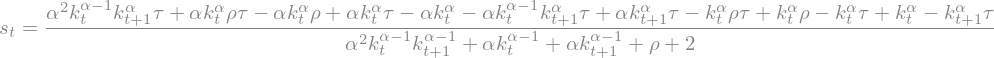

In [573]:
# We go through the same steps as earlier 
c1t, c2t1, wt, wt1, rt1, rho, lam, st, alpha, kt, kt1, n, tau = symbols('c1t c2t1 w_t w_{t+1} r_{t+1} rho lambda s_t alpha k_t k_{t+1} n tau')

rt = alpha  * kt**(alpha - 1)
rt1 = alpha  * kt1**(alpha - 1)
wt = (1 - alpha)  * kt**alpha
wt1 = (1 - alpha)  * kt1**alpha
c1t = (1-tau)*wt - st
c2t1 = (1+rt1) * st + tau * wt1

u_prime = lambda c: 1 / c

savings_rate = sp.Eq(c1t, (1 + rt)*c2t1 / (1 + rho))

optimal_savings = sp.solve(savings_rate, st)[0]

ste=sp.Eq(st , optimal_savings)
print("Savings rate in PAYG system")
ste


Capital accumulation in PAYG system


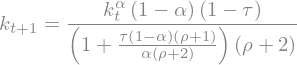

In [574]:
kt1e=sp.Eq(kt1, optimal_savings)
kt1paygo=sp.Eq(kt1, (1 / (1 + (1 + rho) * (1 - alpha) / (2 + rho) * (tau / alpha))) * ((1 / (2 + rho))) * (1 - tau) * wt)
print("Capital accumulation in PAYG system")
kt1paygo



The new element in this is the PAYG contribution rate $\tau$. Higher contribution reduces capital accumulation by decreasing the portion of income available for investment.

Steady state solution in PAYG system


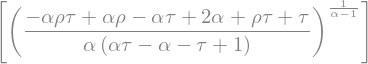

In [575]:
steady_state_eq = kt1paygo.subs(kt1, kt)
steady_state_solution = sp.solve(steady_state_eq, kt)
print("Steady state solution in PAYG system")
steady_state_solution


In [576]:
Steady_state_numsPAYG = sp.lambdify((rho,alpha,tau),steady_state_solution)
print("Steady state value in PAYG system")
Steady_state_numsPAYG(0.03, 0.35, 0.1)

Steady state value in PAYG system


In [577]:
rho = 0.03
alpha = 0.35
tau = 0.1

kss=((1-alpha)/((2+rho))**1/(1-alpha))

obj = lambda k: k - (1 / (1 + (1 + rho) * (1 - alpha) / (2 + rho) * (tau / alpha))) * ((1 / ((2 + rho))) * (1 - tau) * (1 - alpha)  * k**alpha)

resultPAYG = optimize.root_scalar(obj,bracket=[1e-10,10],method='bisect') 
resultPAYG.root;

initializing the model:
calling .setup()
calling .allocate()
simulation done in 0.00 secs


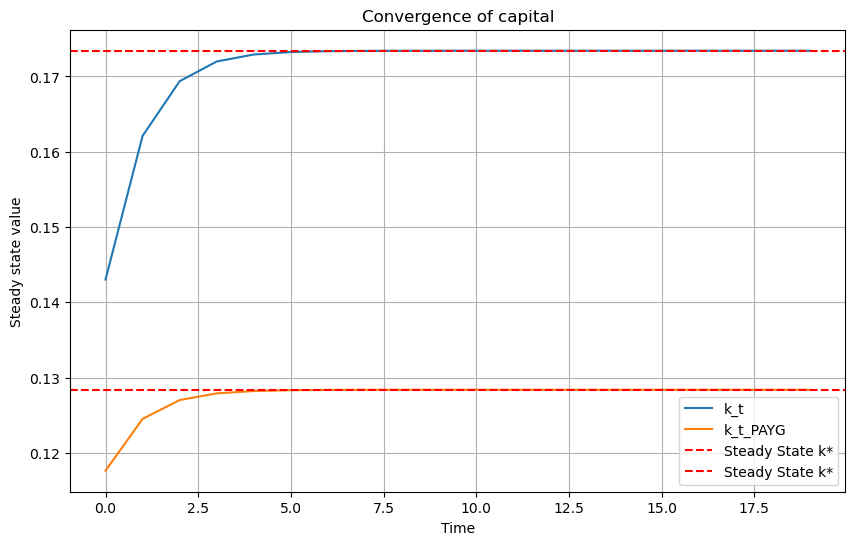

In [578]:
# We now call our model simulation of the PAYG system
model = OLGPAYG()

par = model.par
sim = model.sim

par.tau=0.1
model.simulate()
plt.figure(figsize=(10, 6))
plt.plot(sim_k_original, label='k_t')
plt.plot(model.sim.k, label='k_t_PAYG')  # Plotting k_t over time
plt.xlabel('Time')
plt.ylabel('Steady state value')
plt.title('Convergence of capital')
plt.axhline(y=result.root, color='r', linestyle='--', label='Steady State k*')
plt.axhline(y=resultPAYG.root, color='r', linestyle='--', label='Steady State k*')
plt.legend()
plt.grid(True)
plt.show()

sim_k_tau1 = model.sim.k.copy()

The graph shows the convergence of capital $k_t$ over time in a standard OLG model (blue line) and a PAYG system (orange line) toward their respective steady-state values (dashed red lines). The standard model reaches a higher steady-state capital ($k*$ around 0.173) compared to the PAYG system ($k*$ around 0.13). This indicates that the PAYG system results in lower steady-state capital due to contributions of current pension benefits, reducing the capital in the future. It appears that there is slightly faster convergence in the PAYG system compared to the standard OLG model. 

We will now try to vary the values of $\tau$, and see what happens to the level of steady state and the speed of convergence

In [579]:
# We set new parameter values of tau
par.tau=0.05
tauchange1=Steady_state_numsPAYG(0.03, 0.35, 0.05)
model.simulate()
sim_k_tau2 = model.sim.k.copy()

par.tau=0.15
tauchange2=Steady_state_numsPAYG(0.03, 0.35, 0.15)
model.simulate()

simulation done in 0.00 secs
simulation done in 0.00 secs


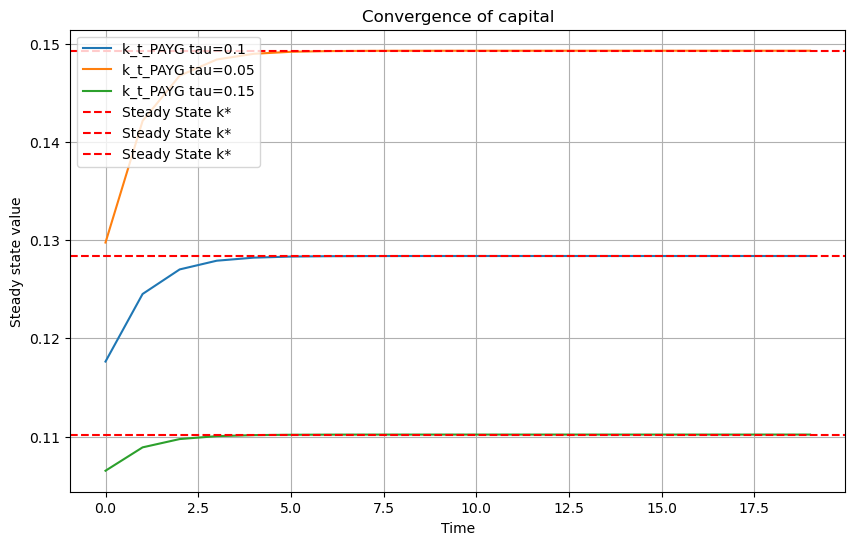

In [580]:
# We plot the convergense of capital for different values of tau
plt.figure(figsize=(10, 6))
plt.plot(sim_k_tau1, label='k_t_PAYG tau=0.1')
plt.plot(sim_k_tau2, label='k_t_PAYG tau=0.05')
plt.plot(model.sim.k, label='k_t_PAYG tau=0.15')
plt.xlabel('Time')
plt.ylabel('Steady state value')
plt.title('Convergence of capital')
plt.axhline(y=tauchange1, color='r', linestyle='--', label='Steady State k*')
plt.axhline(y=tauchange2, color='r', linestyle='--', label='Steady State k*')
plt.axhline(y=resultPAYG.root, color='r', linestyle='--', label='Steady State k*')
plt.legend()
plt.grid(True)
plt.show()

In this graph we see the convergense and level of steady state for three different values of the PAYG contribution rate. We see that the higher the contribution rate $\tau$ the lower the steady state capital is, and the slower the convergence is. When $\tau$ is high, a larger portion of an individual's income is diverted to the PAYG pension system as contributions.  This reduces the disposable income available for private savings, as individuals have less income left after making the contributions. A lower contribution rate allows for more savings and investment, leading to a higher steady-state capital.